# Actor-Critic on CartPole-v1

This notebook implements two Actor-Critic variants on **CartPole-v1** and exports three academic-style figures as **vector PDF** files:

- **Fig 1**: Naive Online Actor-Critic fails — unstable learning across all 5 seeds
- **Fig 2**: A2C vs. Naive AC — mean ± 1 std convergence comparison
- **Fig 3**: Critic (value function) loss — why the naive critic never converges

The code is compatible with both **gymnasium** and **gym** APIs.

## What goes wrong in Naive AC?

| Problem | Naive Actor-Critic | A2C (fixed) |
|---------|-------------------|-------------|
| Advantage estimation | One-step TD δ (high variance) | GAE with λ=0.95 (lower variance) |
| Learning rates | Same LR for actor & critic | Critic LR > Actor LR (two-timescale) |
| Entropy regularization | None → premature collapse | Entropy bonus (coeff=0.01) |
| Gradient clipping | None → catastrophic steps | Max-norm clip = 0.5 |
| Update granularity | Online, one step at a time | Batch over full episode |


In [15]:
# If needed, uncomment one of the following:
# !pip install gymnasium[classic-control]
# !pip install gym==0.26.2

In [16]:
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

try:
    import gymnasium as gym
    GYM_BACKEND = 'gymnasium'
except ImportError:
    import gym
    GYM_BACKEND = 'gym'

print(f'Using backend: {GYM_BACKEND}')
print(f'PyTorch version: {torch.__version__}')

Using backend: gymnasium
PyTorch version: 2.9.0+cu126


In [17]:
# -------------------------
# Global configuration
# -------------------------
ENV_NAME     = 'CartPole-v1'
SEEDS        = [0, 1, 2, 3, 4]
NUM_EPISODES = 500
GAMMA        = 0.99
GAE_LAMBDA   = 0.95
HIDDEN_DIM   = 128
SMOOTH_WINDOW = 20

# Naive AC: one learning rate for everything (the bug)
NAIVE_LR = 5e-3

# A2C: two-timescale learning rates
ACTOR_LR      = 3e-4
CRITIC_LR     = 1e-3   # higher than actor — critic must converge first
ENTROPY_COEFF = 0.01
GRAD_CLIP     = 0.5

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
FIG_DIR = Path('.')    # figures saved alongside the notebook

BLUE  = '#2166AC'
RED   = '#D6604D'
GREEN = '#4DAC26'
GRAY  = '#808080'

plt.rcParams.update({
    'font.family':    'serif',
    'font.serif':     ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size':       12,
    'axes.labelsize':  12,
    'axes.titlesize':  13,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'pdf.fonttype':    42,
    'ps.fonttype':     42,
})

print(f'Device: {DEVICE}')

Device: cuda


In [18]:
# -------------------------
# Utility functions
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def reset_env(env, seed=None):
    if seed is not None:
        try:
            out = env.reset(seed=seed)
        except TypeError:
            if hasattr(env, 'seed'):
                env.seed(seed)
            out = env.reset()
    else:
        out = env.reset()
    state = out[0] if isinstance(out, tuple) else out
    return np.asarray(state, dtype=np.float32)


def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
    else:
        next_state, reward, done, info = out
    return np.asarray(next_state, dtype=np.float32), float(reward), bool(done), info


def moving_average(x, window=20):
    x = np.asarray(x, dtype=np.float64)
    out = np.empty_like(x)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        out[i] = x[start:i + 1].mean()
    return out


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.8, color='0.85')
    ax.set_axisbelow(True)

In [19]:
# -------------------------
# Networks
# Both methods use the exact same architecture.
# The difference is entirely in how they are trained.
# -------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return Categorical(logits=self.net(x))


class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [20]:
# -------------------------
# Generalized Advantage Estimation (Schulman et al., 2015)
# -------------------------
def compute_gae(rewards, values, next_value, dones, gamma, gae_lambda):
    """
    GAE: A_t = sum_l (gamma*lambda)^l * delta_{t+l}
    where delta_t = r_t + gamma*V(s_{t+1}) - V(s_t).

    Lower lambda -> higher bias, lower variance (closer to one-step TD).
    Higher lambda -> lower bias, higher variance (closer to Monte Carlo).
    lambda=0.95 is a good default that balances both.
    """
    n          = len(rewards)
    values_arr = np.array(values, dtype=np.float32)
    advantages = np.zeros(n, dtype=np.float32)
    gae        = 0.0

    for t in reversed(range(n)):
        v_next = 0.0 if dones[t] else (values_arr[t + 1] if t < n - 1 else next_value)
        delta  = rewards[t] + gamma * v_next - values_arr[t]
        gae    = delta + gamma * gae_lambda * (0.0 if dones[t] else gae)
        advantages[t] = gae

    returns = advantages + values_arr
    return advantages, returns

In [21]:
# -------------------------
# Naive Online Actor-Critic
# -------------------------
def train_naive_ac(env_name, seed, num_episodes, gamma, lr, hidden_dim):
    """
    Four failure modes baked in:
      Fault 1 — Per-step TD(0) advantage: high-variance gradient signal.
                Each update sees only (r + gamma*V(s') - V(s)), which is noisy.
      Fault 2 — Same LR for actor & critic: two-timescale condition violated.
                Theory (Konda & Tsitsiklis, 2003) requires critic to converge
                faster than actor; identical LRs break this.
      Fault 3 — No entropy bonus: policy collapses to a deterministic action
                before it has explored enough.
      Fault 4 — No gradient clipping: a single bad step can blow up parameters.
    """
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy       = PolicyNetwork(state_dim, action_dim, hidden_dim).to(DEVICE)
    value        = ValueNetwork(state_dim, hidden_dim).to(DEVICE)
    actor_optim  = torch.optim.Adam(policy.parameters(), lr=lr)
    critic_optim = torch.optim.Adam(value.parameters(),  lr=lr)   # Fault 2: same LR

    episode_returns  = []
    critic_loss_hist = []
    advantage_hist   = []

    for ep in range(num_episodes):
        state     = reset_env(env, seed=seed if ep == 0 else None)
        done      = False
        ep_reward = 0.0
        ep_c_losses  = []
        ep_advantages = []

        while not done:
            state_t  = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            dist     = policy(state_t)
            action   = dist.sample()
            log_prob = dist.log_prob(action).squeeze()   # Fault 3: no entropy term

            next_state, reward, done, _ = step_env(env, action.item())
            next_t = torch.tensor(next_state, dtype=torch.float32, device=DEVICE).unsqueeze(0)

            # Fault 1: one-step TD advantage (high variance)
            with torch.no_grad():
                v_next = 0.0 if done else value(next_t).item()
            v_curr    = value(state_t).squeeze()
            td_target = torch.tensor(reward + gamma * v_next,
                                     dtype=torch.float32, device=DEVICE)
            advantage = td_target - v_curr

            # Critic update — Fault 4: no gradient clipping
            c_loss = advantage.pow(2)
            critic_optim.zero_grad()
            c_loss.backward()
            critic_optim.step()
            ep_c_losses.append(c_loss.item())
            ep_advantages.append(abs(advantage.item()))

            # Actor update — Fault 4: no gradient clipping
            a_loss = -log_prob * advantage.detach()
            actor_optim.zero_grad()
            a_loss.backward()
            actor_optim.step()

            state      = next_state
            ep_reward += reward

        episode_returns.append(ep_reward)
        critic_loss_hist.append(float(np.mean(ep_c_losses))  if ep_c_losses  else 0.0)
        advantage_hist.append(float(np.mean(ep_advantages)) if ep_advantages else 0.0)

    env.close()
    return {
        'returns':       np.array(episode_returns,  dtype=np.float32),
        'critic_losses': np.array(critic_loss_hist, dtype=np.float32),
        'advantages':    np.array(advantage_hist,   dtype=np.float32),
    }

In [22]:
# -------------------------
# Advantage Actor-Critic (A2C)
# -------------------------
def train_a2c(env_name, seed, num_episodes, gamma, gae_lambda,
              actor_lr, critic_lr, entropy_coeff, grad_clip, hidden_dim):
    """
    Each fault fixed:
      Fix 1 — Full-episode rollout + GAE (lambda=0.95): much lower-variance advantages.
      Fix 2 — critic_lr > actor_lr: critic converges faster, giving stable baselines
               before the actor makes large updates (two-timescale principle).
      Fix 3 — Entropy bonus: prevents premature policy collapse.
      Fix 4 — Gradient clipping: bounds the size of each parameter update.
    """
    set_seed(seed)
    env        = gym.make(env_name)
    state_dim  = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy       = PolicyNetwork(state_dim, action_dim, hidden_dim).to(DEVICE)
    value        = ValueNetwork(state_dim, hidden_dim).to(DEVICE)
    actor_optim  = torch.optim.Adam(policy.parameters(), lr=actor_lr)
    critic_optim = torch.optim.Adam(value.parameters(),  lr=critic_lr)  # Fix 2

    episode_returns  = []
    critic_loss_hist = []
    advantage_hist   = []

    for ep in range(num_episodes):
        state = reset_env(env, seed=seed if ep == 0 else None)
        done  = False

        ep_states  = []
        ep_actions = []
        ep_rewards = []
        ep_values  = []
        ep_dones   = []

        # ── Rollout phase (no gradients) ─────────────────────
        with torch.no_grad():
            while not done:
                state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                dist    = policy(state_t)
                v       = value(state_t).item()
                action  = dist.sample()

                next_state, reward, done, _ = step_env(env, action.item())

                ep_states.append(state)
                ep_actions.append(action.item())
                ep_rewards.append(reward)
                ep_values.append(v)
                ep_dones.append(done)
                state = next_state

            last_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            last_v = 0.0 if done else value(last_t).item()

        # ── GAE advantage estimation (Fix 1) ─────────────────
        advantages, returns = compute_gae(
            ep_rewards, ep_values, last_v, ep_dones, gamma, gae_lambda
        )
        ep_mean_adv = float(np.mean(np.abs(advantages)))
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        states_t  = torch.tensor(np.array(ep_states), dtype=torch.float32, device=DEVICE)
        actions_t = torch.tensor(ep_actions,           dtype=torch.long,    device=DEVICE)
        adv_t     = torch.tensor(advantages,           dtype=torch.float32, device=DEVICE)
        ret_t     = torch.tensor(returns,              dtype=torch.float32, device=DEVICE)

        # ── Critic update (higher LR — converges first) ──────
        values_pred = value(states_t)
        c_loss      = F.mse_loss(values_pred, ret_t)
        critic_optim.zero_grad()
        c_loss.backward()
        torch.nn.utils.clip_grad_norm_(value.parameters(), grad_clip)   # Fix 4
        critic_optim.step()

        # ── Actor update (lower LR + entropy bonus) ───────────
        dist_new  = policy(states_t)
        log_probs = dist_new.log_prob(actions_t)
        entropy   = dist_new.entropy().mean()
        a_loss    = -(log_probs * adv_t).mean() - entropy_coeff * entropy   # Fix 3
        actor_optim.zero_grad()
        a_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)  # Fix 4
        actor_optim.step()

        episode_returns.append(sum(ep_rewards))
        critic_loss_hist.append(c_loss.item())
        advantage_hist.append(ep_mean_adv)

    env.close()
    return {
        'returns':       np.array(episode_returns,  dtype=np.float32),
        'critic_losses': np.array(critic_loss_hist, dtype=np.float32),
        'advantages':    np.array(advantage_hist,   dtype=np.float32),
    }

In [23]:
# -------------------------
# Multi-seed runner
# -------------------------
def run_multi_seed(train_fn, label, **kwargs):
    all_returns, all_c_losses, all_advantages = [], [], []
    print(f'Running: {label}')
    for seed in SEEDS:
        result = train_fn(env_name=ENV_NAME, seed=seed,
                          num_episodes=NUM_EPISODES, **kwargs)
        all_returns.append(result['returns'])
        all_c_losses.append(result['critic_losses'])
        all_advantages.append(result['advantages'])
        print(f'  Seed {seed:>2d} | Final-20 mean: {result["returns"][-20:].mean():.2f}')
    return {
        'returns':       np.stack(all_returns,    axis=0),
        'critic_losses': np.stack(all_c_losses,   axis=0),
        'advantages':    np.stack(all_advantages, axis=0),
    }


naive_results = run_multi_seed(
    train_naive_ac, 'Naive Actor-Critic',
    gamma=GAMMA, lr=NAIVE_LR, hidden_dim=HIDDEN_DIM,
)

a2c_results = run_multi_seed(
    train_a2c, 'A2C',
    gamma=GAMMA, gae_lambda=GAE_LAMBDA,
    actor_lr=ACTOR_LR, critic_lr=CRITIC_LR,
    entropy_coeff=ENTROPY_COEFF, grad_clip=GRAD_CLIP,
    hidden_dim=HIDDEN_DIM,
)

Running: Naive Actor-Critic
  Seed  0 | Final-20 mean: 9.60
  Seed  1 | Final-20 mean: 9.35
  Seed  2 | Final-20 mean: 9.45
  Seed  3 | Final-20 mean: 9.65
  Seed  4 | Final-20 mean: 9.15
Running: A2C
  Seed  0 | Final-20 mean: 215.85
  Seed  1 | Final-20 mean: 341.75
  Seed  2 | Final-20 mean: 392.10
  Seed  3 | Final-20 mean: 355.90
  Seed  4 | Final-20 mean: 225.45


In [24]:
# -------------------------
# Plotting helper
# -------------------------
def plot_mean_std(ax, data, color, label, window=20, clip_lower=None, clip_upper=None):
    smoothed = np.vstack([moving_average(run, window) for run in data])
    mean = smoothed.mean(axis=0)
    std  = smoothed.std(axis=0)
    x    = np.arange(1, len(mean) + 1)
    lo   = mean - std
    hi   = mean + std
    if clip_lower is not None:
        lo = np.maximum(lo, clip_lower)
    if clip_upper is not None:
        hi = np.minimum(hi, clip_upper)
    ax.plot(x, mean, color=color, linewidth=2.2, label=label, zorder=3)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0, zorder=2)
    return mean, std

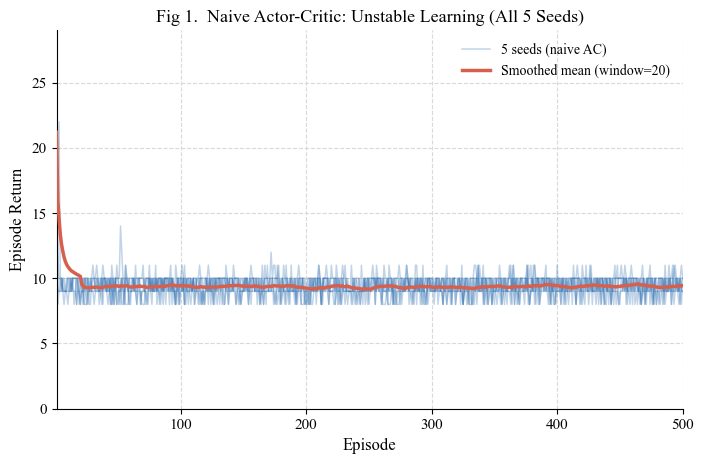

Saved: C:\Users\admin\Desktop\RL\notes\actor-critic\fig1_naive_ac_failure.pdf


In [25]:
# -------------------------
# Fig 1 — Naive Actor-Critic: All 5 Seeds Fail
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))
episodes = np.arange(1, NUM_EPISODES + 1)
raw = naive_results['returns']

for idx in range(len(SEEDS)):
    ax.plot(episodes, raw[idx],
            color=BLUE, alpha=0.28, linewidth=1.1,
            label='5 seeds (naive AC)' if idx == 0 else None,
            zorder=1)

smoothed_mean = moving_average(raw.mean(axis=0), window=SMOOTH_WINDOW)
ax.plot(episodes, smoothed_mean,
        color=RED, linewidth=2.5,
        label=f'Smoothed mean (window={SMOOTH_WINDOW})',
        zorder=3)

style_axes(ax)
ax.set_title('Fig 1.  Naive Actor-Critic: Unstable Learning (All 5 Seeds)')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Return')
ax.set_xlim(1, NUM_EPISODES)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()

fig1_path = FIG_DIR / 'fig1_naive_ac_failure.pdf'
fig.savefig(fig1_path, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved: {fig1_path.resolve()}')

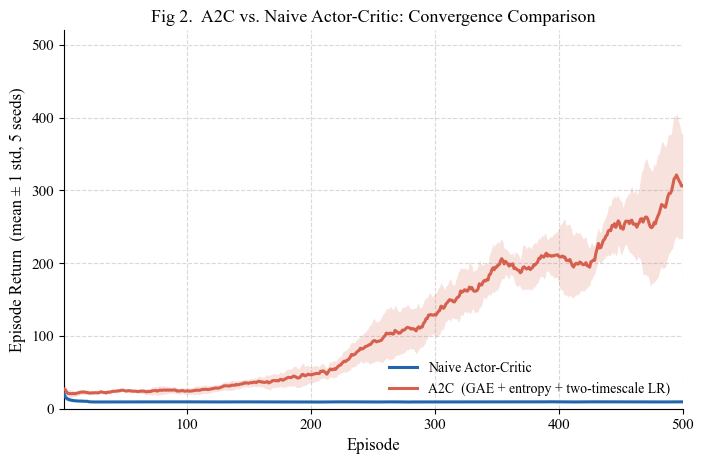

Saved: C:\Users\admin\Desktop\RL\notes\actor-critic\fig2_a2c_vs_naive.pdf


In [26]:
# -------------------------
# Fig 2 — A2C vs. Naive AC: Convergence Comparison
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))

plot_mean_std(ax, naive_results['returns'],
              BLUE, 'Naive Actor-Critic',
              window=SMOOTH_WINDOW, clip_lower=0, clip_upper=500)
plot_mean_std(ax, a2c_results['returns'],
              RED, 'A2C  (GAE + entropy + two-timescale LR)',
              window=SMOOTH_WINDOW, clip_lower=0, clip_upper=500)

style_axes(ax)
ax.set_title('Fig 2.  A2C vs. Naive Actor-Critic: Convergence Comparison')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Return  (mean \u00b1 1 std, 5 seeds)')
ax.set_xlim(1, NUM_EPISODES)
ax.set_ylim(0, 520)
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()

fig2_path = FIG_DIR / 'fig2_a2c_vs_naive.pdf'
fig.savefig(fig2_path, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved: {fig2_path.resolve()}')

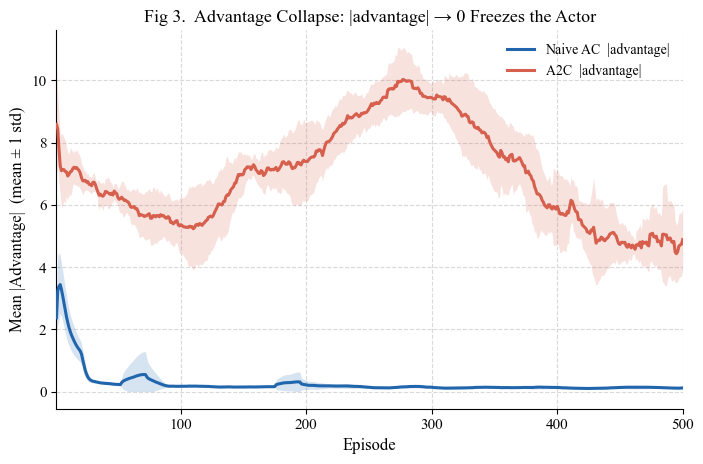

Saved: C:\Users\admin\Desktop\RL\notes\actor-critic\fig3_advantage_collapse.pdf


In [27]:
# -------------------------
# Fig 3 — Mean |Advantage| per Episode
# When advantage → 0 the policy gradient vanishes and the actor freezes.
# Naive AC: advantage collapses to ~0 within 50 episodes (actor frozen).
# A2C: advantage stays large and grows with the policy — ongoing learning.
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))

plot_mean_std(ax, naive_results['advantages'],
              BLUE, 'Naive AC  |advantage|',
              window=SMOOTH_WINDOW, clip_lower=0)
plot_mean_std(ax, a2c_results['advantages'],
              RED, 'A2C  |advantage|',
              window=SMOOTH_WINDOW, clip_lower=0)

style_axes(ax)
ax.set_title('Fig 3.  Advantage Collapse: |advantage| → 0 Freezes the Actor')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean |Advantage|  (mean ± 1 std)')
ax.set_xlim(1, NUM_EPISODES)
ax.legend(frameon=False, loc='upper right')
fig.tight_layout()

fig3_path = FIG_DIR / 'fig3_advantage_collapse.pdf'
fig.savefig(fig3_path, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved: {fig3_path.resolve()}')

In [28]:
# -------------------------
# Summary
# -------------------------
def print_summary(name, results):
    r = results['returns'][:, -20:].mean(axis=1)
    print(f'{name:<45s}  Final-20: {r.mean():.2f} \u00b1 {r.std():.2f}')


print_summary('Naive Actor-Critic', naive_results)
print_summary('A2C (GAE + entropy + two-timescale LR)', a2c_results)

print('\nFigures saved:')
for p in [fig1_path, fig2_path, fig3_path]:
    print(f'  {p.resolve()}')

Naive Actor-Critic                             Final-20: 9.44 ± 0.18
A2C (GAE + entropy + two-timescale LR)         Final-20: 306.21 ± 71.83

Figures saved:
  C:\Users\admin\Desktop\RL\notes\actor-critic\fig1_naive_ac_failure.pdf
  C:\Users\admin\Desktop\RL\notes\actor-critic\fig2_a2c_vs_naive.pdf
  C:\Users\admin\Desktop\RL\notes\actor-critic\fig3_advantage_collapse.pdf
